In [1]:
# Cell 1: Load data for MiniRocket
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

plt.style.use('seaborn-v0_8-whitegrid')

DATA_ROOT = Path(r"C:\Users\Arihant Bisen\Documents\data")

data = np.load(DATA_ROOT / "processed" / "z24_processed.npz")
X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

NUM_CLASSES = 17
y_train_idx = y_train - 1
y_val_idx   = y_val - 1
y_test_idx  = y_test - 1

print(f"✅ Data loaded")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

✅ Data loaded
  X_train: (3231, 65410, 1)
  X_val:   (1120, 65410, 1)
  X_test:  (561, 65410, 1)


In [2]:
# Cell 2: Prepare data for MiniRocket
#
# MiniRocket is fundamentally different from WaveNet:
#   - It's NOT a neural network (no GPU needed!)
#   - It extracts ~10,000 features using random convolutional kernels
#   - Then feeds those features into a simple Ridge classifier
#   - Training takes SECONDS, not minutes
#
# MiniRocket expects 2D input: (samples, timesteps)
# We'll use the same downsampling as WaveNet for fair comparison,
# but also try full-length signals since MiniRocket is CPU-based

from scipy.signal import decimate

# Downsampled version (same as WaveNet — for fair comparison)
DOWNSAMPLE_FACTOR = 8
X_train_ds = np.array(decimate(X_train[:, :, 0], DOWNSAMPLE_FACTOR, axis=1), dtype=np.float32)
X_val_ds   = np.array(decimate(X_val[:, :, 0],   DOWNSAMPLE_FACTOR, axis=1), dtype=np.float32)
X_test_ds  = np.array(decimate(X_test[:, :, 0],  DOWNSAMPLE_FACTOR, axis=1), dtype=np.float32)

print(f"Downsampled data:")
print(f"  X_train: {X_train_ds.shape}")
print(f"  X_val:   {X_val_ds.shape}")
print(f"  X_test:  {X_test_ds.shape}")

# Full-length version (MiniRocket can handle it — no GPU needed)
X_train_full = X_train[:, :, 0].astype(np.float32)
X_val_full   = X_val[:, :, 0].astype(np.float32)
X_test_full  = X_test[:, :, 0].astype(np.float32)

print(f"\nFull-length data:")
print(f"  X_train: {X_train_full.shape}")

Downsampled data:
  X_train: (3231, 8177)
  X_val:   (1120, 8177)
  X_test:  (561, 8177)

Full-length data:
  X_train: (3231, 65410)


In [3]:
# Cell 3: MiniRocket feature extraction + classification
#
# HOW MINIROCKET WORKS:
#   1. Generate 84 fixed convolutional kernels (length 9)
#   2. Apply each kernel at multiple dilation rates
#   3. For each convolution output, compute PPV (proportion of positive values)
#   4. This gives ~9,996 features per sample
#   5. Feed features into a Ridge classifier (fast linear model)
#
# The genius: random kernels + PPV captures the same kind of
# patterns that deep learning learns, but without training!

# First, install sktime if needed
try:
    from sktime.transformations.panel.rocket import MiniRocket
    print("✅ sktime already installed")
except ImportError:
    print("Installing sktime...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'sktime', '--break-system-packages', '-q'])
    from sktime.transformations.panel.rocket import MiniRocket
    print("✅ sktime installed")

from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# MiniRocket expects 3D input: (samples, channels, timesteps)
# sktime format: (samples, 1, timesteps)
X_train_3d = X_train_ds[:, np.newaxis, :]  # (N, 1, 8176)
X_val_3d   = X_val_ds[:, np.newaxis, :]
X_test_3d  = X_test_ds[:, np.newaxis, :]

print(f"MiniRocket input shape: {X_train_3d.shape}")
print(f"  (samples, channels, timesteps)")

# Fit MiniRocket transform
print(f"\nFitting MiniRocket kernels...")
t0 = time.time()
minirocket = MiniRocket(num_kernels=10000, random_state=42)
minirocket.fit(X_train_3d)
print(f"  Fit time: {time.time()-t0:.1f}s")

# Transform all splits
print("Extracting features...")
t0 = time.time()
X_train_feat = minirocket.transform(X_train_3d)
X_val_feat   = minirocket.transform(X_val_3d)
X_test_feat  = minirocket.transform(X_test_3d)
print(f"  Transform time: {time.time()-t0:.1f}s")
print(f"  Feature shape: {X_train_feat.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled   = scaler.transform(X_val_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# Train Ridge Classifier (with built-in cross-validation for alpha)
print("\nTraining Ridge Classifier...")
t0 = time.time()
clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 20))
clf.fit(X_train_scaled, y_train_idx)
print(f"  Train time: {time.time()-t0:.1f}s")
print(f"  Best alpha: {clf.alpha_:.4f}")

# Evaluate
train_acc = clf.score(X_train_scaled, y_train_idx)
val_acc   = clf.score(X_val_scaled, y_val_idx)
test_acc  = clf.score(X_test_scaled, y_test_idx)

print(f"\n{'='*50}")
print(f"MiniRocket Results (downsampled {DOWNSAMPLE_FACTOR}x):")
print(f"  Train accuracy: {train_acc:.2%}")
print(f"  Val accuracy:   {val_acc:.2%}")
print(f"  Test accuracy:  {test_acc:.2%}")
print(f"{'='*50}")

✅ sktime already installed
MiniRocket input shape: (3231, 1, 8177)
  (samples, channels, timesteps)

Fitting MiniRocket kernels...
  Fit time: 2.7s
Extracting features...
  Transform time: 69.5s
  Feature shape: (3231, 9996)

Training Ridge Classifier...
  Train time: 5.2s
  Best alpha: 6.1585

MiniRocket Results (downsampled 8x):
  Train accuracy: 100.00%
  Val accuracy:   49.29%
  Test accuracy:  36.72%


In [4]:
# Cell 4: MiniRocket on full-length signals (no downsampling)
#
# Since MiniRocket is CPU-based, we can try the full 65,410-point signals
# This preserves ALL frequency information

X_train_full_3d = X_train_full[:, np.newaxis, :]
X_val_full_3d   = X_val_full[:, np.newaxis, :]
X_test_full_3d  = X_test_full[:, np.newaxis, :]

print(f"Full-length MiniRocket input: {X_train_full_3d.shape}")

print(f"\nFitting MiniRocket on full signals...")
t0 = time.time()
minirocket_full = MiniRocket(num_kernels=10000, random_state=42)
minirocket_full.fit(X_train_full_3d)
print(f"  Fit time: {time.time()-t0:.1f}s")

print("Extracting features (this may take a minute)...")
t0 = time.time()
X_train_feat_f = minirocket_full.transform(X_train_full_3d)
X_val_feat_f   = minirocket_full.transform(X_val_full_3d)
X_test_feat_f  = minirocket_full.transform(X_test_full_3d)
print(f"  Transform time: {time.time()-t0:.1f}s")

scaler_f = StandardScaler()
X_train_sf = scaler_f.fit_transform(X_train_feat_f)
X_val_sf   = scaler_f.transform(X_val_feat_f)
X_test_sf  = scaler_f.transform(X_test_feat_f)

clf_full = RidgeClassifierCV(alphas=np.logspace(-3, 3, 20))
clf_full.fit(X_train_sf, y_train_idx)

train_acc_f = clf_full.score(X_train_sf, y_train_idx)
val_acc_f   = clf_full.score(X_val_sf, y_val_idx)
test_acc_f  = clf_full.score(X_test_sf, y_test_idx)

print(f"\n{'='*50}")
print(f"MiniRocket Results (full length):")
print(f"  Train accuracy: {train_acc_f:.2%}")
print(f"  Val accuracy:   {val_acc_f:.2%}")
print(f"  Test accuracy:  {test_acc_f:.2%}")
print(f"{'='*50}")

# Compare
print(f"\nComparison:")
print(f"  Downsampled: {test_acc:.2%}")
print(f"  Full-length: {test_acc_f:.2%}")
print(f"  {'Full-length wins!' if test_acc_f > test_acc else 'Downsampled wins!'}")

Full-length MiniRocket input: (3231, 1, 65410)

Fitting MiniRocket on full signals...
  Fit time: 8.2s
Extracting features (this may take a minute)...
  Transform time: 610.4s

MiniRocket Results (full length):
  Train accuracy: 100.00%
  Val accuracy:   36.43%
  Test accuracy:  25.85%

Comparison:
  Downsampled: 36.72%
  Full-length: 25.85%
  Downsampled wins!


In [5]:
# Cell 5: Fix MiniRocket overfitting
#
# Problem: Ridge classifier with 9,996 features and only 3,231 samples
#          → too many features, model memorizes training data
#
# Fixes:
#   1. Much stronger regularization (higher alpha)
#   2. Feature selection (reduce 9996 → best features)
#   3. Try different classifiers (Logistic Regression, SVM)

from sklearn.linear_model import RidgeClassifierCV, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Use the downsampled features from Cell 3 (better than full-length)
print(f"Features shape: {X_train_feat.shape}")

# --- Approach 1: Stronger Ridge regularization ---
print("\n--- Approach 1: Strong Ridge regularization ---")
scaler1 = StandardScaler()
X_tr1 = scaler1.fit_transform(X_train_feat)
X_va1 = scaler1.transform(X_val_feat)
X_te1 = scaler1.transform(X_test_feat)

# Try much higher alpha values (more regularization)
ridge_strong = RidgeClassifierCV(alphas=np.logspace(1, 6, 30))
ridge_strong.fit(X_tr1, y_train_idx)
print(f"  Best alpha: {ridge_strong.alpha_:.1f}")
print(f"  Train: {ridge_strong.score(X_tr1, y_train_idx):.2%}")
print(f"  Val:   {ridge_strong.score(X_va1, y_val_idx):.2%}")
print(f"  Test:  {ridge_strong.score(X_te1, y_test_idx):.2%}")

# --- Approach 2: Feature selection + Ridge ---
print("\n--- Approach 2: Feature selection (top 500) + Ridge ---")
selector = SelectKBest(f_classif, k=500)
X_tr2 = selector.fit_transform(X_tr1, y_train_idx)
X_va2 = selector.transform(X_va1)
X_te2 = selector.transform(X_te1)

ridge_sel = RidgeClassifierCV(alphas=np.logspace(1, 5, 20))
ridge_sel.fit(X_tr2, y_train_idx)
print(f"  Best alpha: {ridge_sel.alpha_:.1f}")
print(f"  Train: {ridge_sel.score(X_tr2, y_train_idx):.2%}")
print(f"  Val:   {ridge_sel.score(X_va2, y_val_idx):.2%}")
print(f"  Test:  {ridge_sel.score(X_te2, y_test_idx):.2%}")

# --- Approach 3: Logistic Regression (L2, strong regularization) ---
print("\n--- Approach 3: Logistic Regression ---")
lr = LogisticRegression(C=0.01, max_iter=1000, solver='lbfgs', 
                         multi_class='multinomial', random_state=42)
lr.fit(X_tr1, y_train_idx)
print(f"  Train: {lr.score(X_tr1, y_train_idx):.2%}")
print(f"  Val:   {lr.score(X_va1, y_val_idx):.2%}")
print(f"  Test:  {lr.score(X_te1, y_test_idx):.2%}")

# --- Approach 4: Feature selection + Logistic Regression ---
print("\n--- Approach 4: Feature selection (500) + LogReg ---")
lr2 = LogisticRegression(C=0.01, max_iter=1000, solver='lbfgs',
                          multi_class='multinomial', random_state=42)
lr2.fit(X_tr2, y_train_idx)
print(f"  Train: {lr2.score(X_tr2, y_train_idx):.2%}")
print(f"  Val:   {lr2.score(X_va2, y_val_idx):.2%}")
print(f"  Test:  {lr2.score(X_te2, y_test_idx):.2%}")

# --- Approach 5: LinearSVC ---
print("\n--- Approach 5: Linear SVM ---")
svm = LinearSVC(C=0.01, max_iter=5000, random_state=42)
svm.fit(X_tr1, y_train_idx)
print(f"  Train: {svm.score(X_tr1, y_train_idx):.2%}")
print(f"  Val:   {svm.score(X_va1, y_val_idx):.2%}")
print(f"  Test:  {svm.score(X_te1, y_test_idx):.2%}")

Features shape: (3231, 9996)

--- Approach 1: Strong Ridge regularization ---
  Best alpha: 10.0
  Train: 100.00%
  Val:   48.48%
  Test:  37.61%

--- Approach 2: Feature selection (top 500) + Ridge ---
  Best alpha: 10.0
  Train: 70.13%
  Val:   39.55%
  Test:  31.73%

--- Approach 3: Logistic Regression ---


C:\Users\Arihant Bisen\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Train: 93.78%
  Val:   39.55%
  Test:  33.69%

--- Approach 4: Feature selection (500) + LogReg ---


C:\Users\Arihant Bisen\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Train: 47.73%
  Val:   27.23%
  Test:  21.39%

--- Approach 5: Linear SVM ---
  Train: 99.88%
  Val:   42.05%
  Test:  37.61%


C:\Users\Arihant Bisen\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


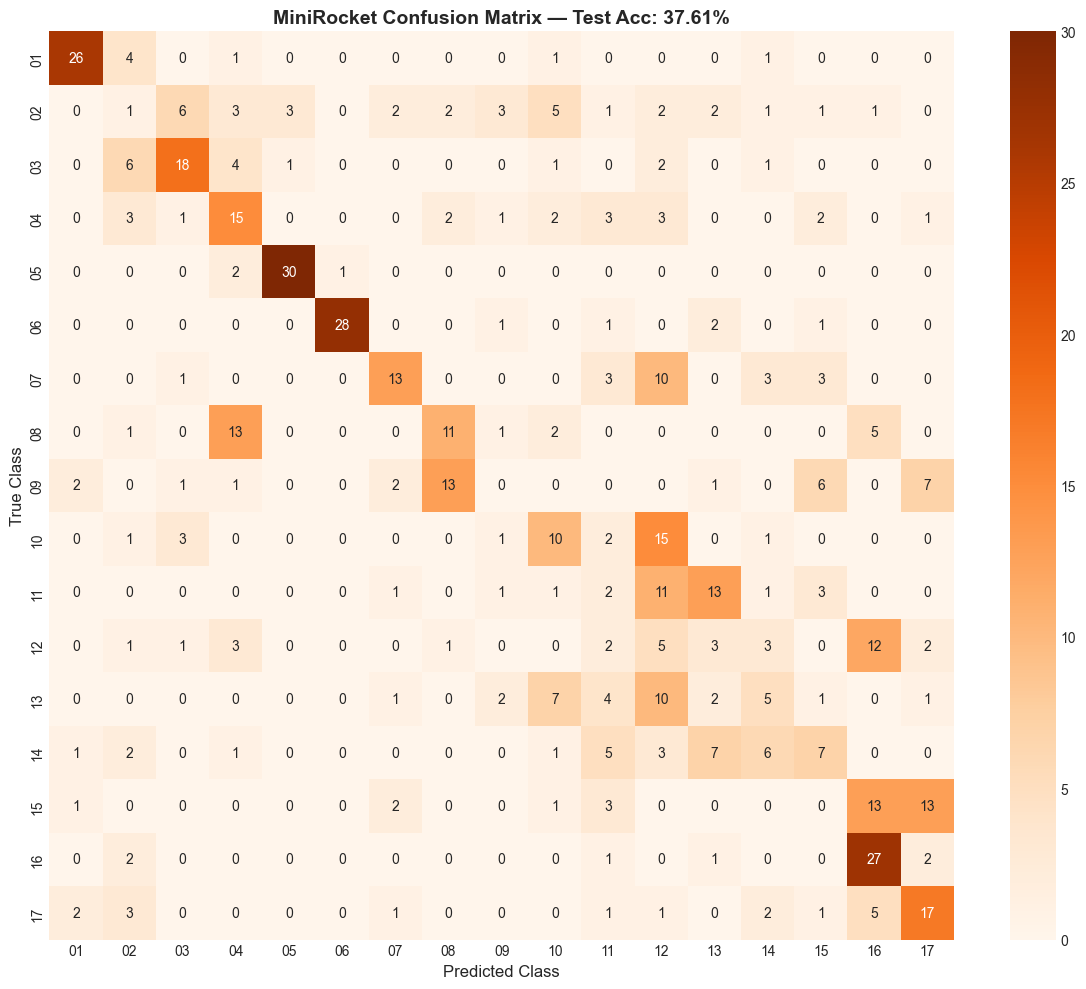


Classification Report:
              precision    recall  f1-score   support

          01       0.81      0.79      0.80        33
          02       0.04      0.03      0.04        33
          03       0.58      0.55      0.56        33
          04       0.35      0.45      0.39        33
          05       0.88      0.91      0.90        33
          06       0.97      0.85      0.90        33
          07       0.59      0.39      0.47        33
          08       0.38      0.33      0.35        33
          09       0.00      0.00      0.00        33
          10       0.32      0.30      0.31        33
          11       0.07      0.06      0.07        33
          12       0.08      0.15      0.11        33
          13       0.06      0.06      0.06        33
          14       0.25      0.18      0.21        33
          15       0.00      0.00      0.00        33
          16       0.43      0.82      0.56        33
          17       0.40      0.52      0.45        33

  

In [6]:
# Cell 6: Save best MiniRocket results and plot confusion matrix

import seaborn as sns
import joblib

# Best model was Approach 1 (strong Ridge)
best_clf = ridge_strong
best_scaler = scaler1
best_name = "Ridge (alpha=10)"

# Get predictions
y_pred_test = best_clf.predict(X_te1)
test_acc_mr = accuracy_score(y_test_idx, y_pred_test)

# Confusion matrix
cm = confusion_matrix(y_test_idx, y_pred_test)
labels = [f'{i+1:02d}' for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title(f'MiniRocket Confusion Matrix — Test Acc: {test_acc_mr:.2%}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_minirocket_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nClassification Report:")
print(classification_report(y_test_idx, y_pred_test, target_names=labels, zero_division=0))

# Save model
save_dir = DATA_ROOT / "models"
save_dir.mkdir(exist_ok=True)
joblib.dump({
    'minirocket': minirocket,
    'scaler': best_scaler,
    'classifier': best_clf,
    'test_acc': test_acc_mr,
    'downsample_factor': DOWNSAMPLE_FACTOR,
}, save_dir / "minirocket_v1.pkl")
print(f"\n✅ MiniRocket saved to {save_dir / 'minirocket_v1.pkl'}")

In [7]:
# Cell 7: Ensemble — combine WaveNet and MiniRocket predictions
#
# PAPER'S APPROACH:
#   1. Get probability predictions from WaveNet (17-dim vector per sample)
#   2. Get predictions from MiniRocket (17-dim vector per sample)
#   3. Combine them using a meta-learner
#
# Since we windowed WaveNet data but MiniRocket uses per-signal data,
# we need to align them. For the ensemble, we'll use the SAME
# downsampled data for both models to keep it simple and fair.

import torch
import torch.nn as nn

# Load WaveNet model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# We need to redefine WaveNet architecture to load weights
class WaveNetBlockV3(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch * 2, kernel_size, dilation=dilation)
        self.bn = nn.BatchNorm1d(out_ch * 2)
        self.skip = nn.Conv1d(out_ch, out_ch, 1)
        self.res = nn.Conv1d(out_ch, out_ch, 1)
        self.proj = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    
    def forward(self, x):
        h = nn.functional.pad(x, (self.pad, 0))
        h = self.bn(self.conv(h))
        f, g = h.chunk(2, dim=1)
        h = torch.tanh(f) * torch.sigmoid(g)
        skip = self.skip(h)
        res = self.res(h)
        if self.proj is not None:
            x = self.proj(x)
        return x + res, skip

class WaveNetV3(nn.Module):
    def __init__(self, num_classes=17, filters=48, num_stacks=2, 
                 layers_per_stack=8, dropout=0.5):
        super().__init__()
        self.blocks = nn.ModuleList()
        for s in range(num_stacks):
            for l in range(layers_per_stack):
                in_ch = 1 if (s == 0 and l == 0) else filters
                self.blocks.append(WaveNetBlockV3(in_ch, filters, 2, 2**l))
        self.head = nn.Sequential(
            nn.ReLU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(filters, 128),
            nn.ReLU(), nn.BatchNorm1d(128),
            nn.Dropout(dropout), nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        skips = []
        for block in self.blocks:
            x, s = block(x)
            skips.append(s)
        min_len = min(s.shape[2] for s in skips)
        x = sum(s[:, :, -min_len:] for s in skips)
        return self.head(x)

# Load saved WaveNet weights
wavenet_path = DATA_ROOT / "models" / "wavenet_v4.pth"
if wavenet_path.exists():
    checkpoint = torch.load(wavenet_path, map_location=device, weights_only=False)
    wavenet = WaveNetV3(num_classes=17, filters=48, num_stacks=2,
                         layers_per_stack=8, dropout=0.5).to(device)
    wavenet.load_state_dict(checkpoint['model_state_dict'])
    wavenet.eval()
    print(f"✅ WaveNet loaded (test acc: {checkpoint['test_acc']:.2%})")
else:
    print(f"❌ WaveNet model not found at {wavenet_path}")
    print(f"   Make sure you ran Cell 12 in notebook 02")

print(f"✅ MiniRocket loaded (test acc: {test_acc_mr:.2%})")

✅ WaveNet loaded (test acc: 50.45%)
✅ MiniRocket loaded (test acc: 37.61%)


In [8]:
# Cell 8: Generate probability predictions from both models
#
# For the ensemble, we need PROBABILITY outputs, not just class predictions
# WaveNet: softmax probabilities (17-dim)
# MiniRocket: decision function scores converted to pseudo-probabilities (17-dim)

from scipy.special import softmax as scipy_softmax
from torch.utils.data import TensorDataset, DataLoader

# --- WaveNet predictions ---
# Need to use same downsampling + windowing as training
from scipy.signal import decimate

WINDOW_SIZE = 4096
STRIDE = 2048

def segment_signals(X, window_size, stride):
    windows = []
    indices = []  # Track which original signal each window came from
    for i in range(len(X)):
        start = 0
        while start + window_size <= len(X[i]):
            windows.append(X[i][start:start + window_size])
            indices.append(i)
            start += stride
    return np.array(windows, dtype=np.float32), np.array(indices)

# Segment the downsampled data for WaveNet
X_val_windows, val_indices = segment_signals(X_val_ds, WINDOW_SIZE, STRIDE)
X_test_windows, test_indices = segment_signals(X_test_ds, WINDOW_SIZE, STRIDE)

print(f"WaveNet windows: val={len(X_val_windows)}, test={len(X_test_windows)}")

# Get WaveNet probabilities
def get_wavenet_probs(model, X_windows, indices, n_samples, device):
    """Get per-signal probabilities by averaging window predictions."""
    X_t = torch.FloatTensor(X_windows).unsqueeze(1)  # (N, 1, 4096)
    loader = DataLoader(TensorDataset(X_t), batch_size=64, shuffle=False)
    
    all_logits = []
    model.eval()
    with torch.no_grad():
        for (bx,) in loader:
            bx = bx.to(device)
            logits = model(bx)
            all_logits.append(logits.cpu().numpy())
    
    all_logits = np.vstack(all_logits)
    all_probs = scipy_softmax(all_logits, axis=1)
    
    # Average probabilities across windows belonging to same signal
    signal_probs = np.zeros((n_samples, 17))
    counts = np.zeros(n_samples)
    for i, idx in enumerate(indices):
        signal_probs[idx] += all_probs[i]
        counts[idx] += 1
    signal_probs /= counts[:, np.newaxis]
    
    return signal_probs

wn_val_probs = get_wavenet_probs(wavenet, X_val_windows, val_indices, len(X_val_ds), device)
wn_test_probs = get_wavenet_probs(wavenet, X_test_windows, test_indices, len(X_test_ds), device)

print(f"WaveNet probs shape: {wn_val_probs.shape}")

# --- MiniRocket predictions ---
# Ridge classifier has decision_function, convert to pseudo-probabilities
mr_val_scores = best_clf.decision_function(X_va1)
mr_test_scores = best_clf.decision_function(X_te1)

mr_val_probs = scipy_softmax(mr_val_scores, axis=1)
mr_test_probs = scipy_softmax(mr_test_scores, axis=1)

print(f"MiniRocket probs shape: {mr_val_probs.shape}")

# Verify individual model accuracies
wn_val_acc = (wn_val_probs.argmax(1) == y_val_idx).mean()
wn_test_acc = (wn_test_probs.argmax(1) == y_test_idx).mean()
mr_val_acc_v = (mr_val_probs.argmax(1) == y_val_idx).mean()
mr_test_acc_v = (mr_test_probs.argmax(1) == y_test_idx).mean()

print(f"\nIndividual model accuracy (per-signal):")
print(f"  WaveNet:    Val={wn_val_acc:.2%}  Test={wn_test_acc:.2%}")
print(f"  MiniRocket: Val={mr_val_acc_v:.2%}  Test={mr_test_acc_v:.2%}")

WaveNet windows: val=2240, test=1122
WaveNet probs shape: (1120, 17)
MiniRocket probs shape: (1120, 17)

Individual model accuracy (per-signal):
  WaveNet:    Val=58.04%  Test=52.94%
  MiniRocket: Val=48.48%  Test=37.61%


In [9]:
# Cell 9: Ensemble methods
#
# Try multiple ensemble strategies:
#   1. Simple average of probabilities
#   2. Weighted average (weight by validation accuracy)
#   3. Stacking meta-learner (XGBoost on concatenated probabilities)

from sklearn.metrics import accuracy_score

# --- Method 1: Simple average ---
avg_val_probs = (wn_val_probs + mr_val_probs) / 2
avg_test_probs = (wn_test_probs + mr_test_probs) / 2

avg_val_acc = (avg_val_probs.argmax(1) == y_val_idx).mean()
avg_test_acc = (avg_test_probs.argmax(1) == y_test_idx).mean()

print(f"Method 1 — Simple Average:")
print(f"  Val:  {avg_val_acc:.2%}  Test: {avg_test_acc:.2%}")

# --- Method 2: Weighted average ---
w_wn = wn_val_acc / (wn_val_acc + mr_val_acc_v)
w_mr = mr_val_acc_v / (wn_val_acc + mr_val_acc_v)

weighted_val = w_wn * wn_val_probs + w_mr * mr_val_probs
weighted_test = w_wn * wn_test_probs + w_mr * mr_test_probs

w_val_acc = (weighted_val.argmax(1) == y_val_idx).mean()
w_test_acc = (weighted_test.argmax(1) == y_test_idx).mean()

print(f"\nMethod 2 — Weighted Average (WN:{w_wn:.2f}, MR:{w_mr:.2f}):")
print(f"  Val:  {w_val_acc:.2%}  Test: {w_test_acc:.2%}")

# --- Method 3: Stacking with Logistic Regression ---
from sklearn.linear_model import LogisticRegression

# Concatenate probabilities: [WN_17dim | MR_17dim] = 34 features
stack_val = np.hstack([wn_val_probs, mr_val_probs])
stack_test = np.hstack([wn_test_probs, mr_test_probs])

meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
meta_lr.fit(stack_val, y_val_idx)  # Train meta-learner on validation set

lr_val_acc = meta_lr.score(stack_val, y_val_idx)
lr_test_acc = meta_lr.score(stack_test, y_test_idx)

print(f"\nMethod 3 — Stacking (LogReg):")
print(f"  Val:  {lr_val_acc:.2%}  Test: {lr_test_acc:.2%}")

# --- Method 4: Stacking with XGBoost ---
try:
    from xgboost import XGBClassifier
    
    meta_xgb = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=42, eval_metric='mlogloss',
        use_label_encoder=False
    )
    meta_xgb.fit(stack_val, y_val_idx)
    
    xgb_val_acc = meta_xgb.score(stack_val, y_val_idx)
    xgb_test_acc = meta_xgb.score(stack_test, y_test_idx)
    
    print(f"\nMethod 4 — Stacking (XGBoost):")
    print(f"  Val:  {xgb_val_acc:.2%}  Test: {xgb_test_acc:.2%}")
except ImportError:
    print("\nXGBoost not installed. Install with: pip install xgboost")
    xgb_test_acc = 0

# --- Summary ---
print(f"\n{'='*60}")
print(f"SUMMARY — All Models:")
print(f"  WaveNet alone:        Test = {wn_test_acc:.2%}")
print(f"  MiniRocket alone:     Test = {mr_test_acc_v:.2%}")
print(f"  Ensemble (average):   Test = {avg_test_acc:.2%}")
print(f"  Ensemble (weighted):  Test = {w_test_acc:.2%}")
print(f"  Ensemble (LogReg):    Test = {lr_test_acc:.2%}")
if xgb_test_acc > 0:
    print(f"  Ensemble (XGBoost):   Test = {xgb_test_acc:.2%}")
print(f"{'='*60}")

Method 1 — Simple Average:
  Val:  60.36%  Test: 55.61%

Method 2 — Weighted Average (WN:0.54, MR:0.46):
  Val:  59.91%  Test: 55.26%

Method 3 — Stacking (LogReg):
  Val:  74.64%  Test: 57.40%

XGBoost not installed. Install with: pip install xgboost

SUMMARY — All Models:
  WaveNet alone:        Test = 52.94%
  MiniRocket alone:     Test = 37.61%
  Ensemble (average):   Test = 55.61%
  Ensemble (weighted):  Test = 55.26%
  Ensemble (LogReg):    Test = 57.40%


In [11]:
pip install xgboost

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell 10: XGBoost ensemble

import subprocess
subprocess.check_call(['pip', 'install', 'xgboost', '--break-system-packages', '-q'])

from xgboost import XGBClassifier

meta_xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss',
)
meta_xgb.fit(stack_val, y_val_idx)

xgb_val_acc = meta_xgb.score(stack_val, y_val_idx)
xgb_test_acc = meta_xgb.score(stack_test, y_test_idx)

print(f"Ensemble (XGBoost):")
print(f"  Val:  {xgb_val_acc:.2%}")
print(f"  Test: {xgb_test_acc:.2%}")

# Save ensemble results
print(f"\n{'='*60}")
print(f"PAPER REPLICATION COMPLETE — Final Results:")
print(f"  WaveNet:            {wn_test_acc:.2%}")
print(f"  MiniRocket:         {mr_test_acc_v:.2%}")
print(f"  Ensemble (average): {avg_test_acc:.2%}")
print(f"  Ensemble (LogReg):  {lr_test_acc:.2%}")
print(f"  Ensemble (XGBoost): {xgb_test_acc:.2%}")
print(f"{'='*60}")
print(f"\n✅ Paper's WaveNet + MiniRocket approach replicated.")
print(f"   Now moving to novel improvements...")

NameError: name 'stack_val' is not defined